In [1]:
from optimizer_functions import *
from heuristic_optimizer import solve_large_instance
import pandas as pd
import pprint
from pyomo.opt import TerminationCondition, SolverStatus
from time import time


In [2]:
# ── 1. load datasets ────────────────────────────────────────────────

# Load the trips data
df_raw = pd.read_csv('transit_departure_updated_energy.csv')
#df_raw = df_raw[df_raw['Line ID'] != '1-1'] 
print(f"Trips before cleaning: {df_raw.shape[0]}")

df = process_transit_data(df_raw, tolerance=1, timestep_min=15)
print(f"Trips after cleaning: {df.shape[0]}")

target_lines = ['1-1','1-3','1-4','1-9','1-11','1-13','1-16','1-18','1-19','1-22','1-25','1-28','1-29','1-32','1-33','1-36','1-39','1-51','1-52','1-53','1-54','1-55','1-56','1-57','1-58','1-59','1-61','1-64','1-65','1-70','1-72','1-74','1-76','1-79','1-80','1-81','1-82','1-84','1-85','1-86','1-88','1-90','1-91','1-92','1-93','1-94','1-96','1-107','1-133','1-136','1-185','1-400','1-401']  # Full set of lines
target_lines = ['1-1','1-4','1-11', '1-18', '1-25','1-54','1-60','1-70','1-72','1-80']  # Reduced set for quicker testing
target_lines = target_lines[:1]
df = df[df["Line ID"].isin(target_lines)].copy()
energy_price_data = pd.read_excel('tou_tariffs.xlsx', sheet_name=None)
energy_price = energy_price_data['Sheet1']['Price'].to_list()
energy_price = resample_time_series(energy_price, original_delta=1, target_delta=0.25, method='average')

df.to_excel('optimization_dataset_one.xlsx', index=False)
print(f"Filtered trips: {df.shape[0]}")

Trips before cleaning: 3737
Trips after cleaning: 3629
Filtered trips: 73


In [3]:
# ── 3. Bus system compositon ────────────────────────────────────────────────
# Example 1 - Slow chargers, large batteries
#bus_counts     = [21] [70]
#battery_sizes  = [300] [300]
#charger_counts = [5] [25]
#charger_powers = [80] [80]

# Example 2 - Fast chargers, smaller batteries
#bus_counts     = [24] 
#battery_sizes  = [150]
#charger_counts = [5]
#charger_powers = [400]

bus_counts     = [5] 
battery_sizes  = [300]
charger_counts = [5]
charger_powers = [100]

C_bat, alpha = build_fleet_and_chargers(
    bus_counts, battery_sizes,
    charger_counts, charger_powers
)

In [4]:
# ── 4. extract data sets ───────────────────────────────────────────────
# Extract the necessary data from the DataFrame
start = df['Departure Step'].astype(int).to_list()
end   = df['Arrival Step'].astype(int).to_list()
gama =df['Energy per timestep'].astype(float).to_list()

In [5]:
def binary_search(bus_counts, battery_sizes, charger_powers):
    """
    Modified binary search to find minimum feasible fleet size and charging infrastructure
    """
    def is_feasible(n_buses, n_chargers):
        """Test if solution is feasible with given fleet size"""
        try:
            start_time = time()
            test_C_bat, test_alpha = build_fleet_and_chargers(
                [n_buses], battery_sizes,
                [n_chargers], charger_powers
            )
            
            test_model = optimization(start, end, test_alpha, gama, test_C_bat, energy_price,
                                   E_0=0.2, E_min=0.2, E_max=1.00, E_end=0.2, 
                                   delta_t=0.25, relaxed_binary=False)
            
            solver = SolverFactory('gurobi')
            solver.options['TimeLimit'] = 10800 # 3 hours
            solver.options['MIPGap'] = 0.05  # 5% gap
            results = solver.solve(test_model, tee=False)
            
            solve_time = time() - start_time

            if (results.solver.termination_condition == TerminationCondition.optimal or 
                (results.solver.status == SolverStatus.aborted and 
                 results.solver.termination_condition == TerminationCondition.maxTimeLimit and
                 hasattr(test_model, 'solutions') and 
                 len(test_model.solutions) > 0)):
                print(f"Solution time: {solve_time:.2f} seconds")
                return True, test_model
            print(f"Solution time: {solve_time:.2f} seconds (infeasible)")
            return False, None
        except:
            print("Error occurred during optimization")
            return False, None
    
    total_start_time = time()

    # Phase 1: Find minimum number of buses
    print("Phase 1: Finding minimum number of buses...")
    
    # Try initial bus count
    initial_buses = bus_counts[0]
    is_feasible_sol, model = is_feasible(initial_buses, initial_buses)
    
    if is_feasible_sol:
        right_bus = initial_buses
        left_bus = initial_buses // 2
    else:
        # Try double the buses
        double_buses = initial_buses * 2
        print(f"Initial {initial_buses} buses infeasible, trying {double_buses} buses...")
        is_feasible_sol, model = is_feasible(double_buses, double_buses)
        print(f"Feasible solution found with {double_buses} buses")
        
        if not is_feasible_sol:
            print("Problem infeasible even with double the buses")
            return None, None, None
            
        right_bus = double_buses
        left_bus = initial_buses
    
    min_buses = right_bus
    feasible_model = model
    
    # Binary search for minimum buses
    while right_bus - left_bus > 1:
        mid_bus = (left_bus + right_bus) // 2
        print(f"Testing with {mid_bus} buses...")
        
        is_feasible_sol, model = is_feasible(mid_bus, mid_bus)
        if is_feasible_sol:
            min_buses = mid_bus
            right_bus = mid_bus
            feasible_model = model
            print(f"Feasible solution found with {mid_bus} buses")
        else:
            left_bus = mid_bus
            print(f"Infeasible solution with {mid_bus} buses")
    
    # Phase 2: Find minimum number of chargers
    print(f"\nPhase 2: Finding minimum chargers for {min_buses} buses...")
    
    current_chargers = min_buses
    min_chargers = current_chargers
    step_size = current_chargers // 2
    
    while step_size > 0:
        test_chargers = current_chargers - step_size
        print(f"Testing with {min_buses} buses and {test_chargers} chargers...")
        
        is_feasible_sol, model = is_feasible(min_buses, test_chargers)
        if is_feasible_sol:
            min_chargers = test_chargers
            current_chargers = test_chargers
            feasible_model = model
            print(f"Feasible solution found with {test_chargers} chargers")
        else:
            print(f"Infeasible solution with {test_chargers} chargers")
        
        step_size = step_size // 2
    
    total_time = time() - total_start_time
    print(f"\nTotal binary search time: {total_time:.2f} seconds")
    return min_buses, min_chargers, feasible_model

# Run the binary search
min_buses, min_chargers, feasible_model = binary_search(bus_counts, battery_sizes, charger_powers)

if min_buses is not None:
    print(f"\nFinal results:")
    print(f"Minimum number of buses needed: {min_buses}")
    print(f"Minimum number of chargers needed: {min_chargers}")
    if feasible_model is not None:
        print("Optimal objective value:", pyo.value(feasible_model.obj))
        export_optimization_summary(
            feasible_model,
            vehicle_cost=1200000,    # € per bus
            charger_cost=180000,     # € per charger
            implementation_cost=70000,  # € for charger implementation
            peak_power_price=0.4,    # € per kW
            years=10,
            filename='optimization_summary_slow_charging.xlsx'
            )       
else:
    print("No feasible solution found")
    


Phase 1: Finding minimum number of buses...
Number of trips: 73, Time steps: 96, Buses: 5, Chargers: 5
Parameters initialized
Variables initialized
Objective function defined
Constraints defined
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Model was proven to be infeasible.
Solution time: 1.34 seconds (infeasible)
Initial 5 buses infeasible, trying 10 buses...
Number of trips: 73, Time steps: 96, Buses: 10, Chargers: 10
Parameters initialized
Variables initialized
Objective function defined
Constraints defined
Solution time: 3.06 seconds
Feasible solution found with 10 buses
Testing with 7 buses...
Number of trips: 73, Time steps: 96, Buses: 7, Chargers: 7
Parameters initialized
Variables initialized
Objective function defined
Constraints defined
Solution time: 1.98 seconds
Feasible solution found with 7 buses
Testing with 6 buses...
Number of trips: 73, Time steps: 96, Buses: 6, Chargers: 6
Parameters initialized
Variables initialized
Object

In [11]:
# ── 5. Build your model as before ────────────────────────────────────────────
model = optimization(start, end, alpha, gama, C_bat, energy_price,
                    E_0=0.2, E_min=0.2, E_max=1.00, E_end=0.2, delta_t=0.25, relaxed_binary=False)


Number of trips: 73, Time steps: 96, Buses: 5, Chargers: 5
Parameters initialized
Variables initialized
Objective function defined
Constraints defined


In [ ]:
# ── 6. Configure and solve with warm‐start ──────────────────────────────────          
# ── 6.1. Configure Gurobi options for heuristics & warm‐start ────────────────
'''
solver = SolverFactory('gurobi')
solver.options.update({
    'TimeLimit'      : 1000,      # stop after 6 min
    'MIPGap'         : 0.1,     # 10% optimality gap
    'Heuristics'     : 1.0,      # maximum time to primal heuristics
    'MIPFocus'       : 1,        # focus on finding good feasible solutions
    'Presolve'       : 2,        # aggressive presolve
    'Cuts'           : 3,        # more cutting‐plane generation
    'NodefileStart'  : 0.5,      # start nodefile earlier (in GB)
    'PoolSearchMode' : 2,        # find more solutions
    'ImproveStartTime': 0,       # start improving incumbent immediately
    # 'BarConvTol'   : 1e-4,     # (if using barrier)
})
# ── 6.2. Solve with warmstart turned on ──────────────────────────────────────
results = solver.solve(model,
                       tee=True,
                       warmstart=True)   # tells Pyomo to pass the MIP start to Gurobi

# Print only the optimal objective value
print("Optimal objective value:", pyo.value(model.obj))
'''

Set parameter Username
Academic license - for non-commercial use only - expires 2025-11-18
Read LP format model from file /var/folders/bs/tqpdfpm95n9c4cp994_d9lm00000gn/T/tmpsn_qkpfm.pyomo.lp
Reading time = 0.11 seconds
x1: 10209 rows, 38016 columns, 117746 nonzeros
Read MIP start from file /var/folders/bs/tqpdfpm95n9c4cp994_d9lm00000gn/T/tmpjo1knf0l.gurobi.mst
Set parameter TimeLimit to value 1000
Set parameter MIPGap to value 0.1
Set parameter Heuristics to value 1
Set parameter MIPFocus to value 1
Set parameter Presolve to value 2
Set parameter Cuts to value 3
Set parameter NodefileStart to value 0.5
Set parameter PoolSearchMode to value 2
Set parameter ImproveStartTime to value 0
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[rosetta2] - Darwin 24.6.0 24G90)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 10209 rows, 38016 columns and 117746 nonzeros
Model fingerprint: 0x0b6353da
Variable types: 57

ValueError: No value for uninitialized NumericValue object w_buy[1]

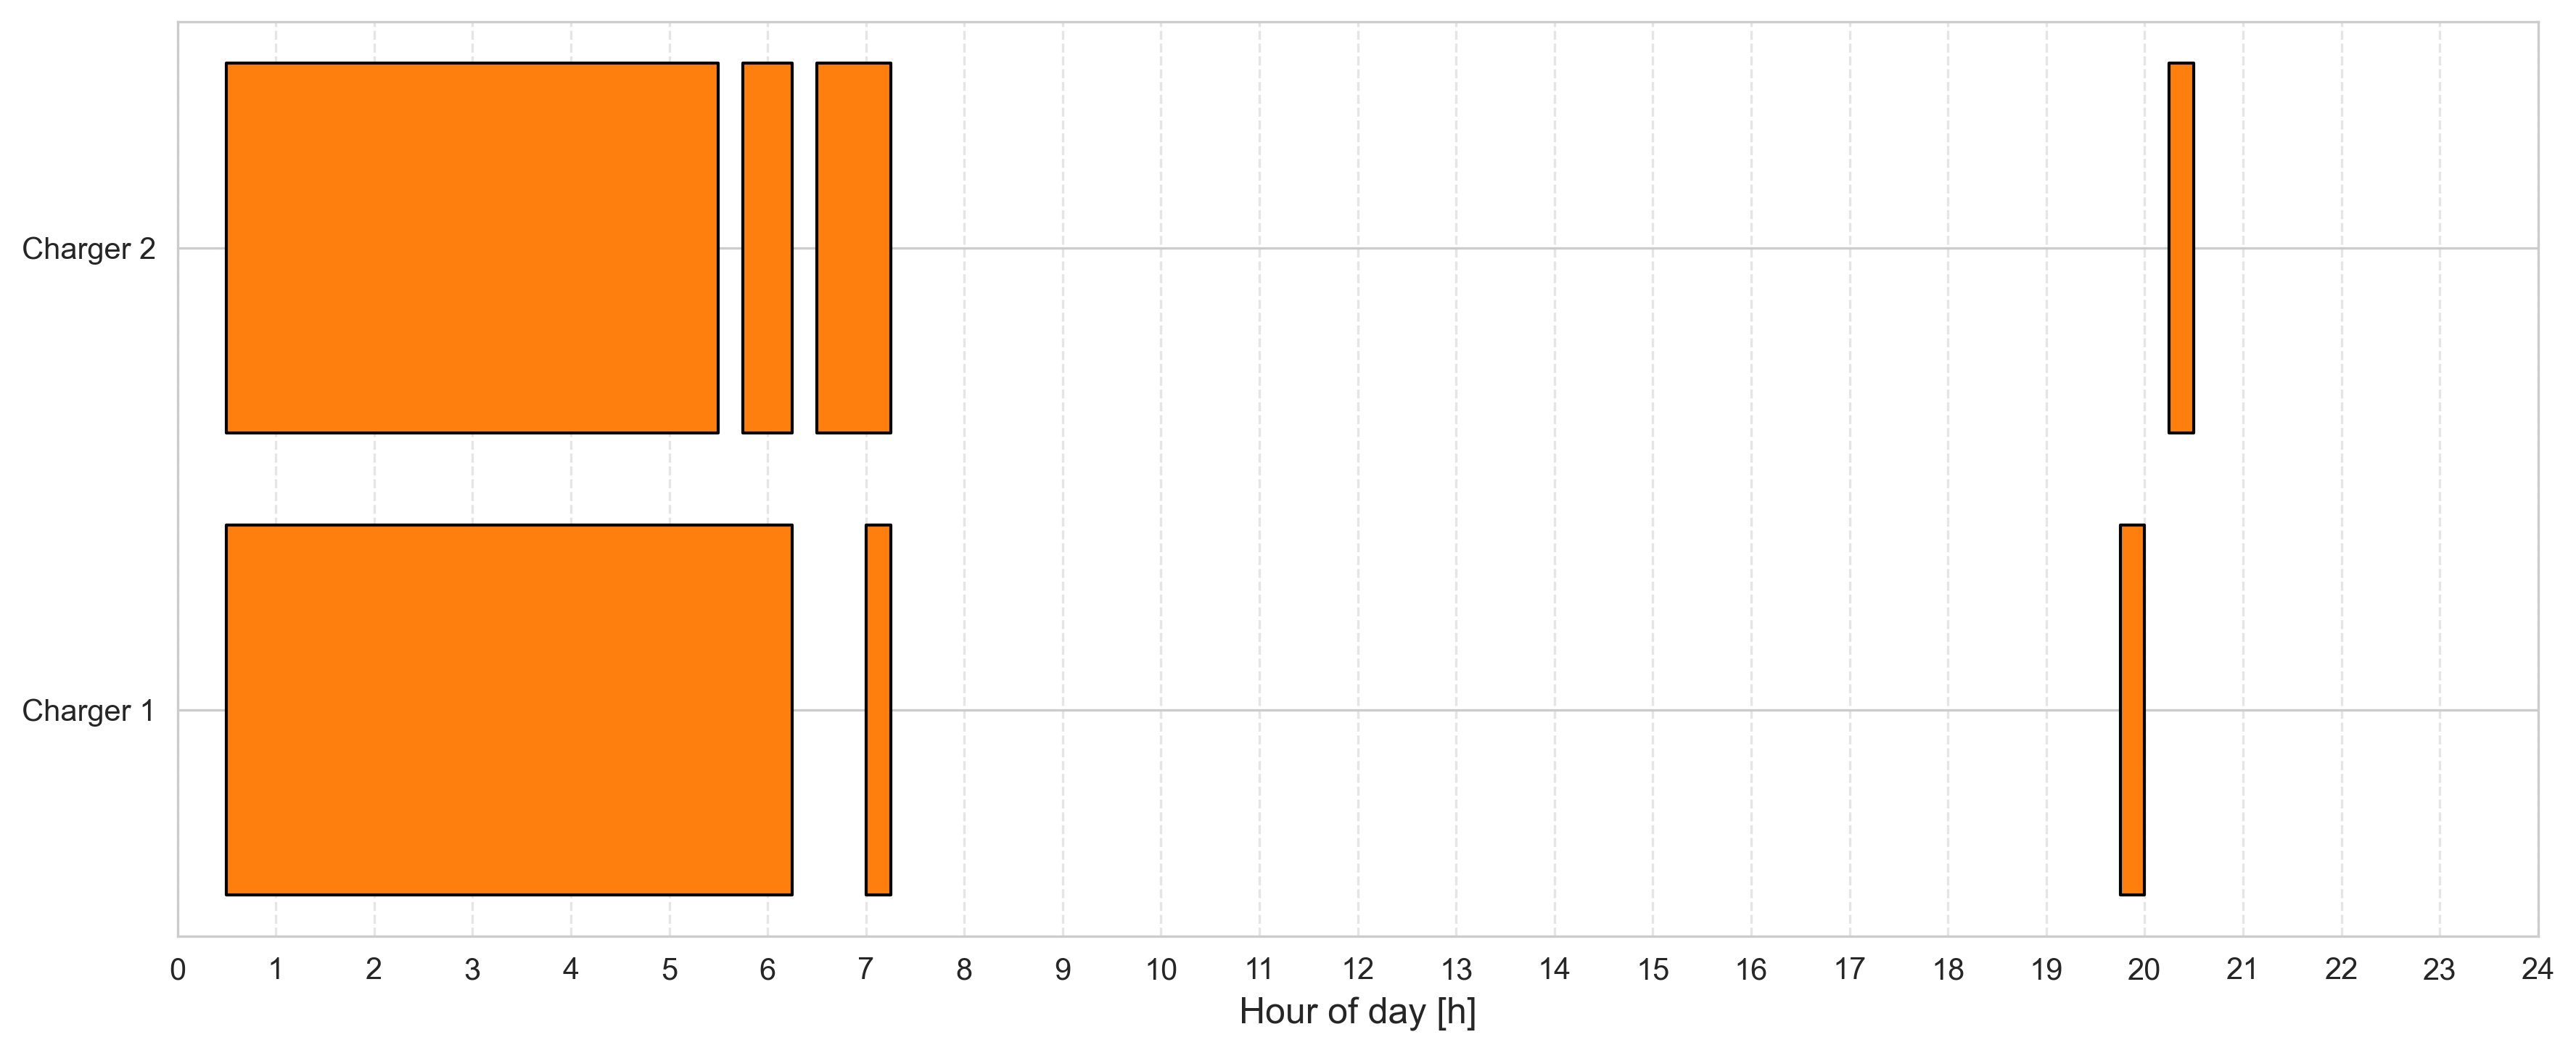

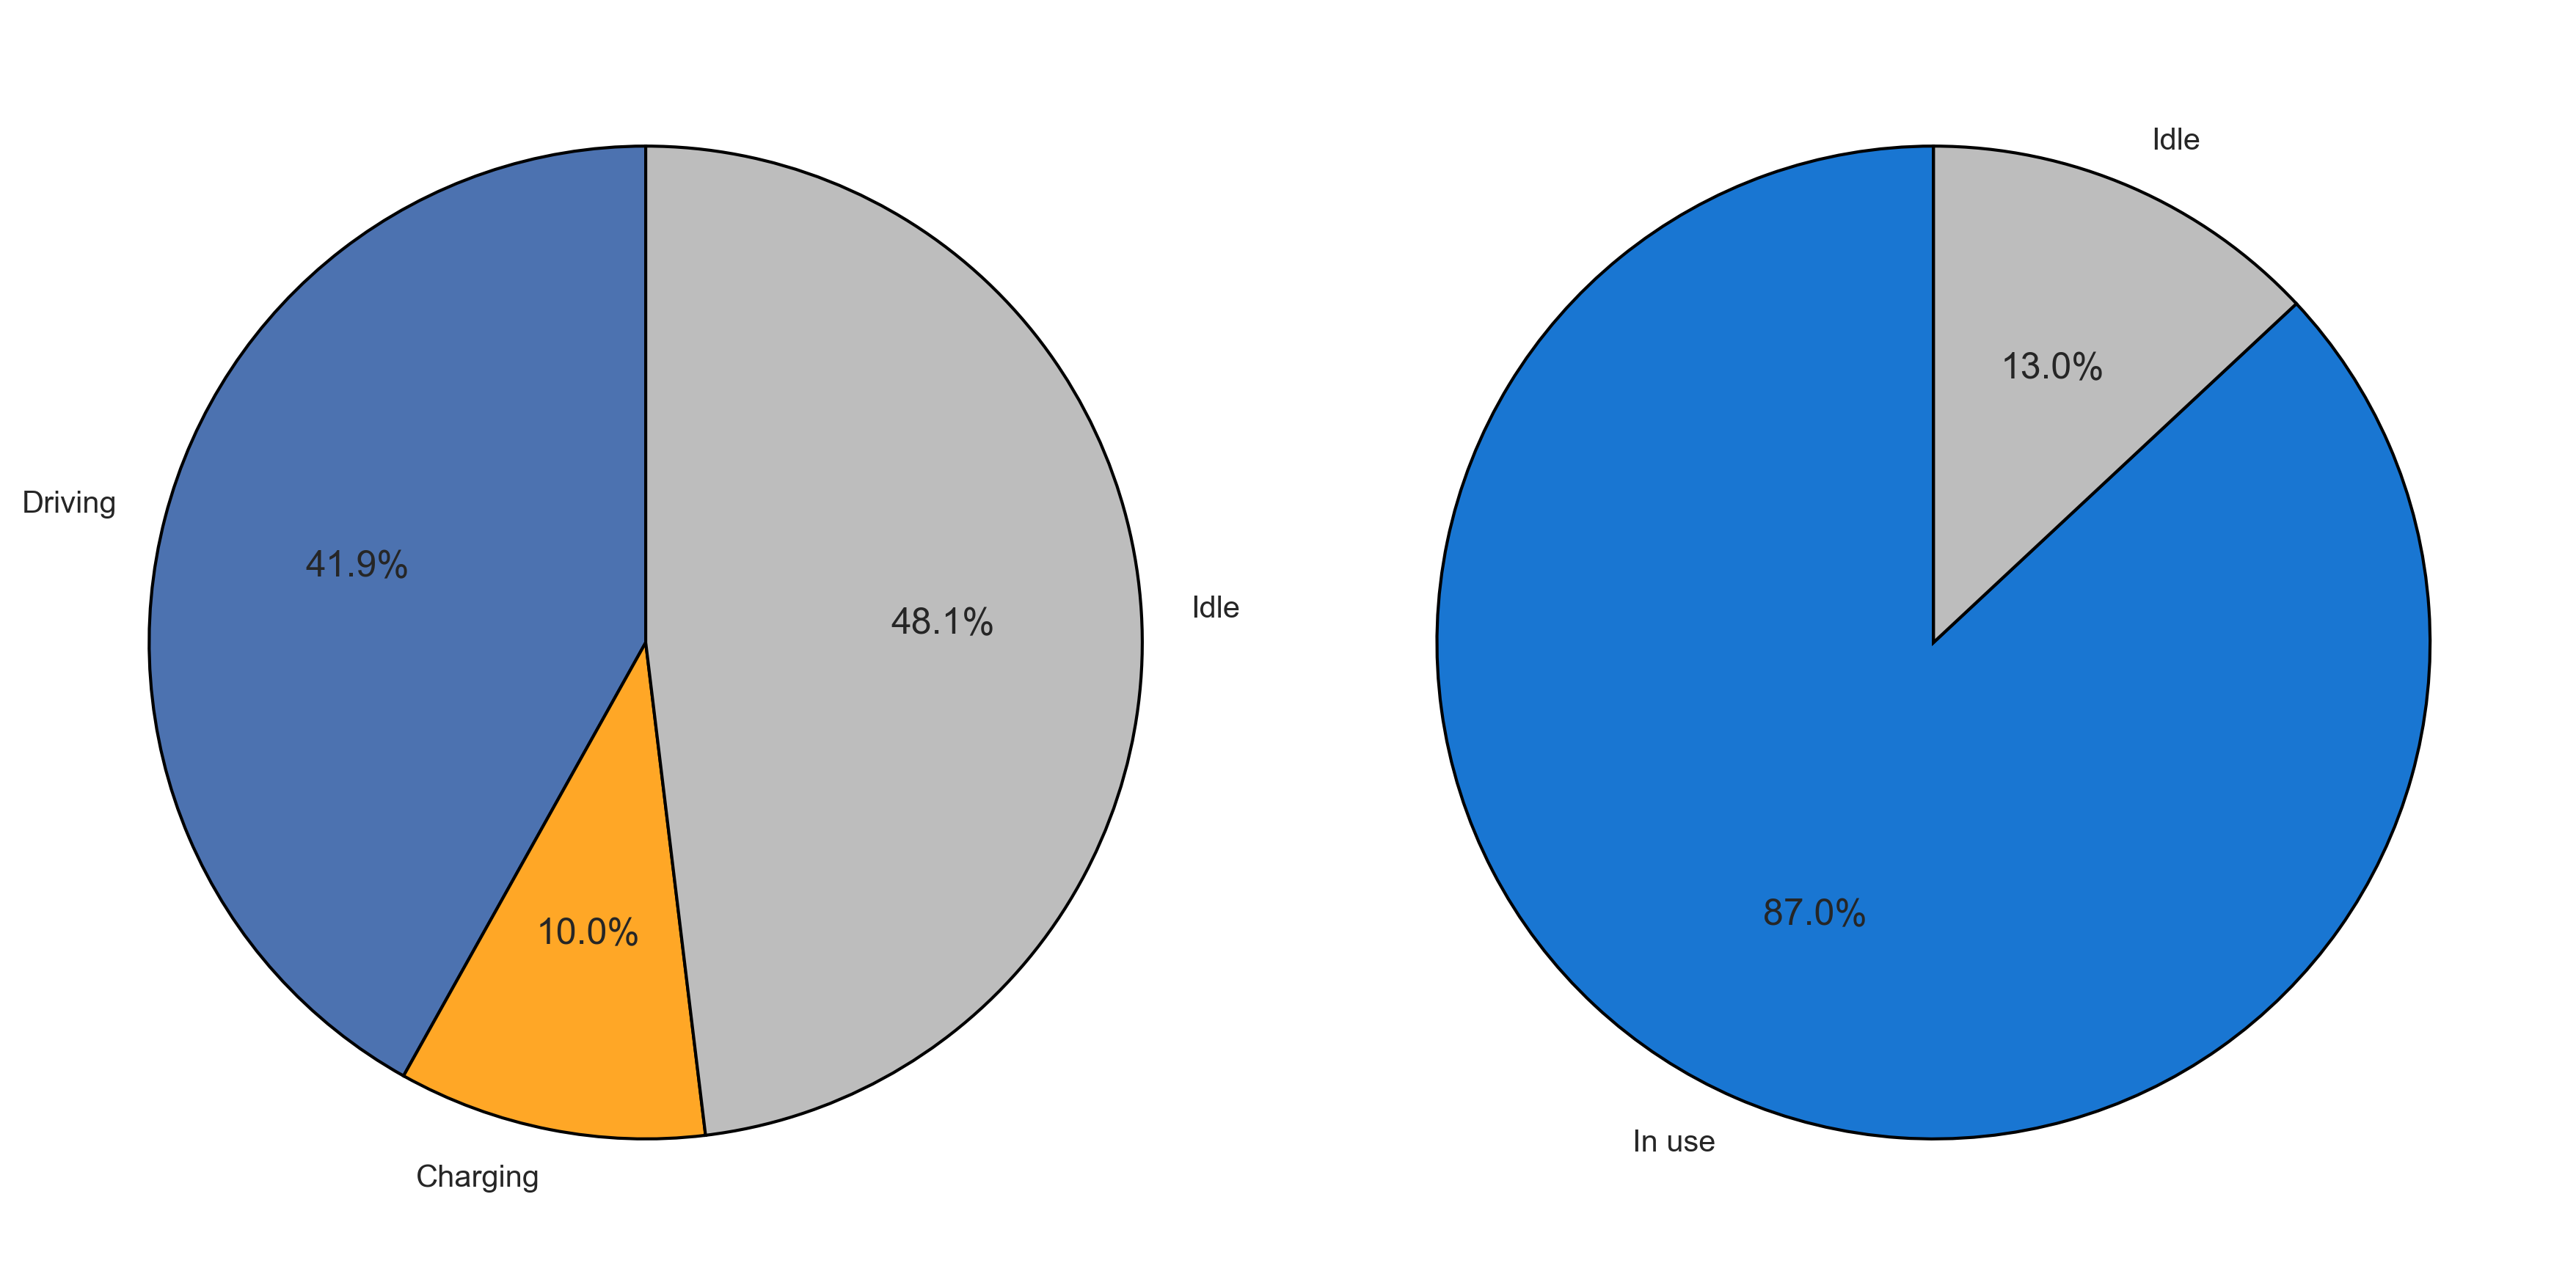

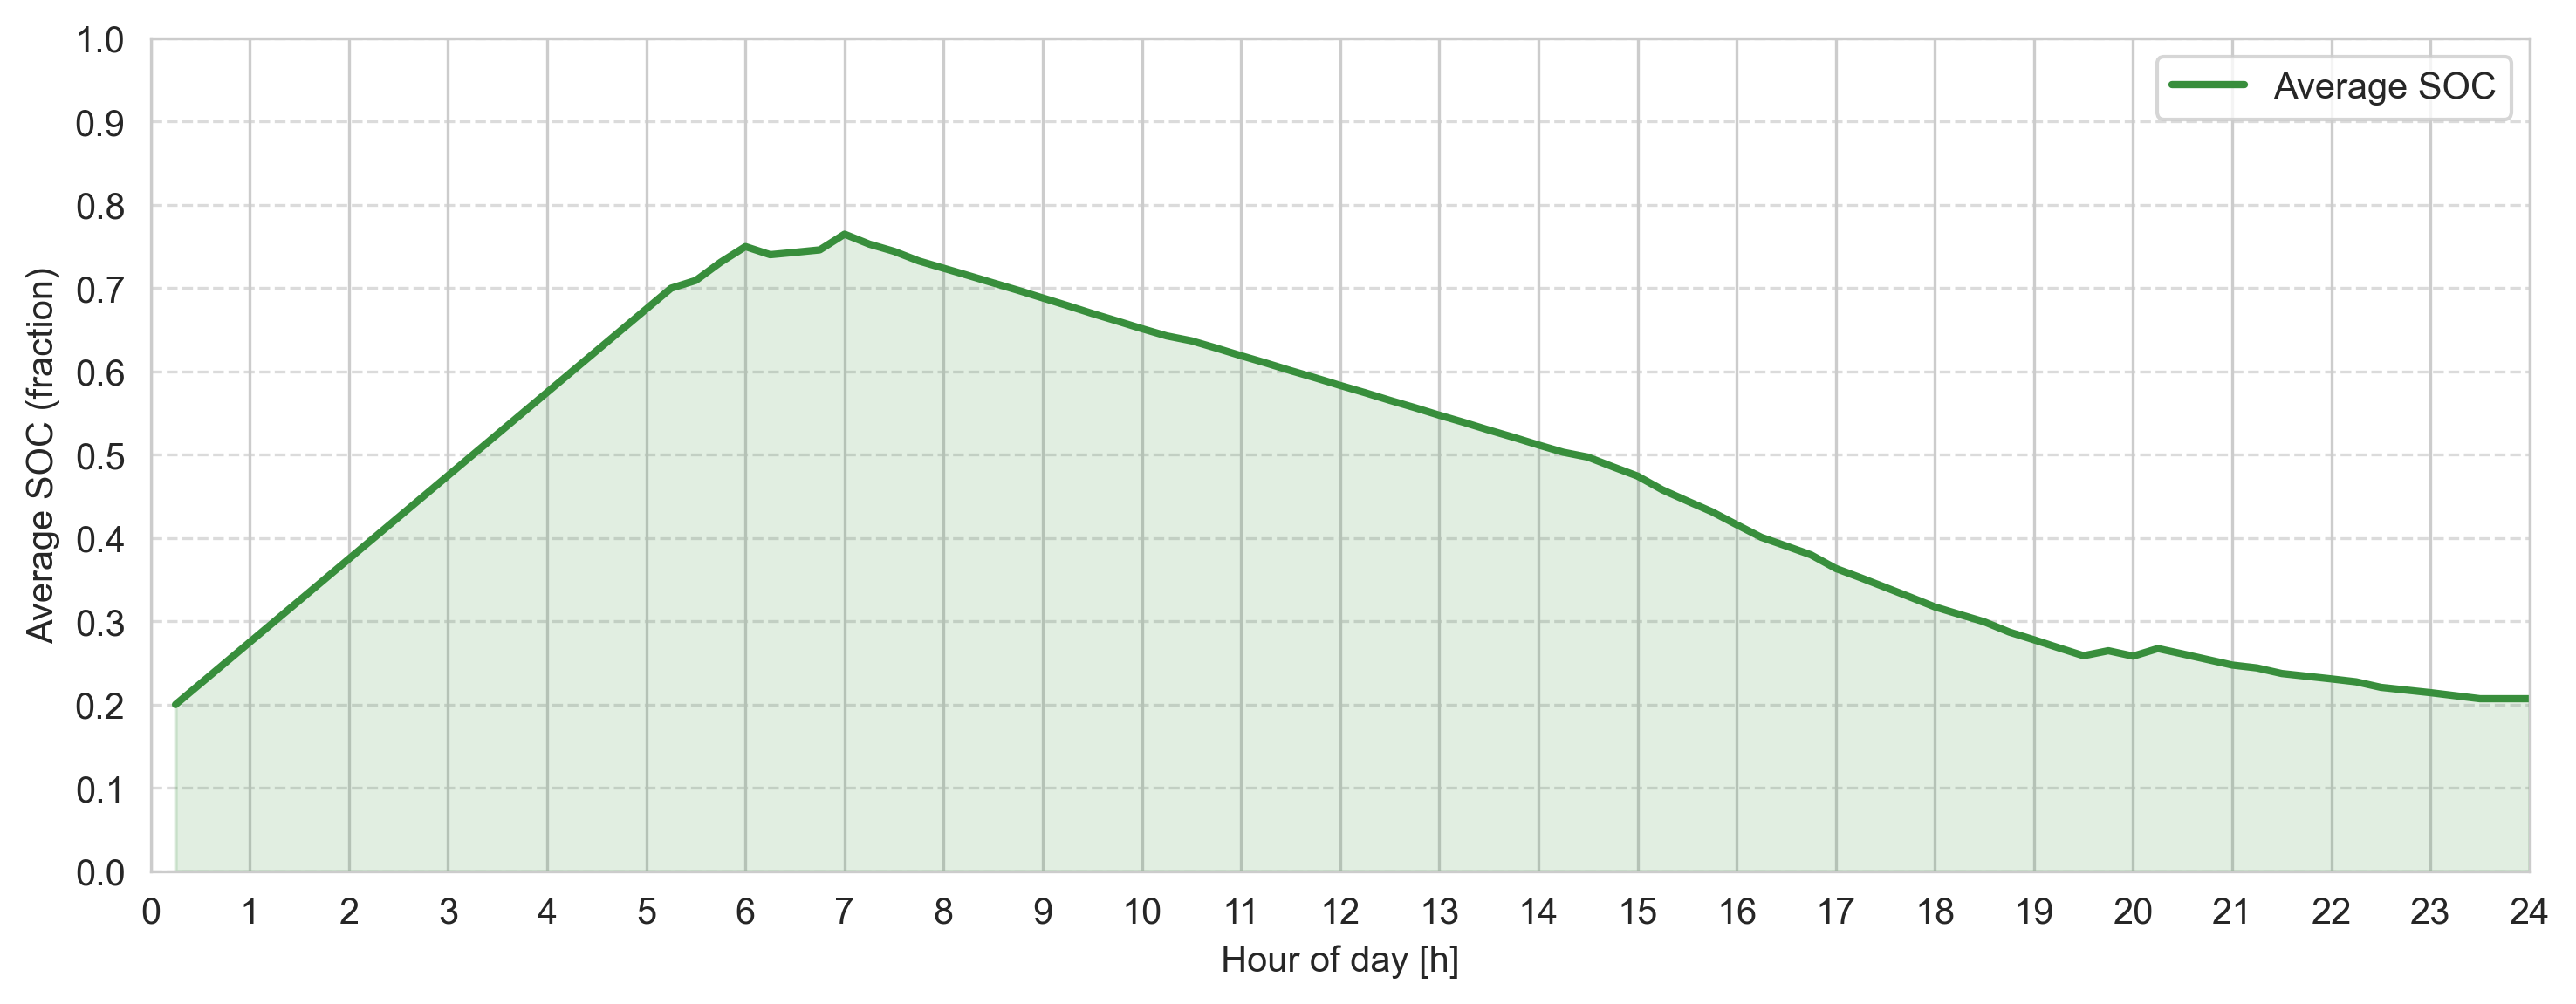

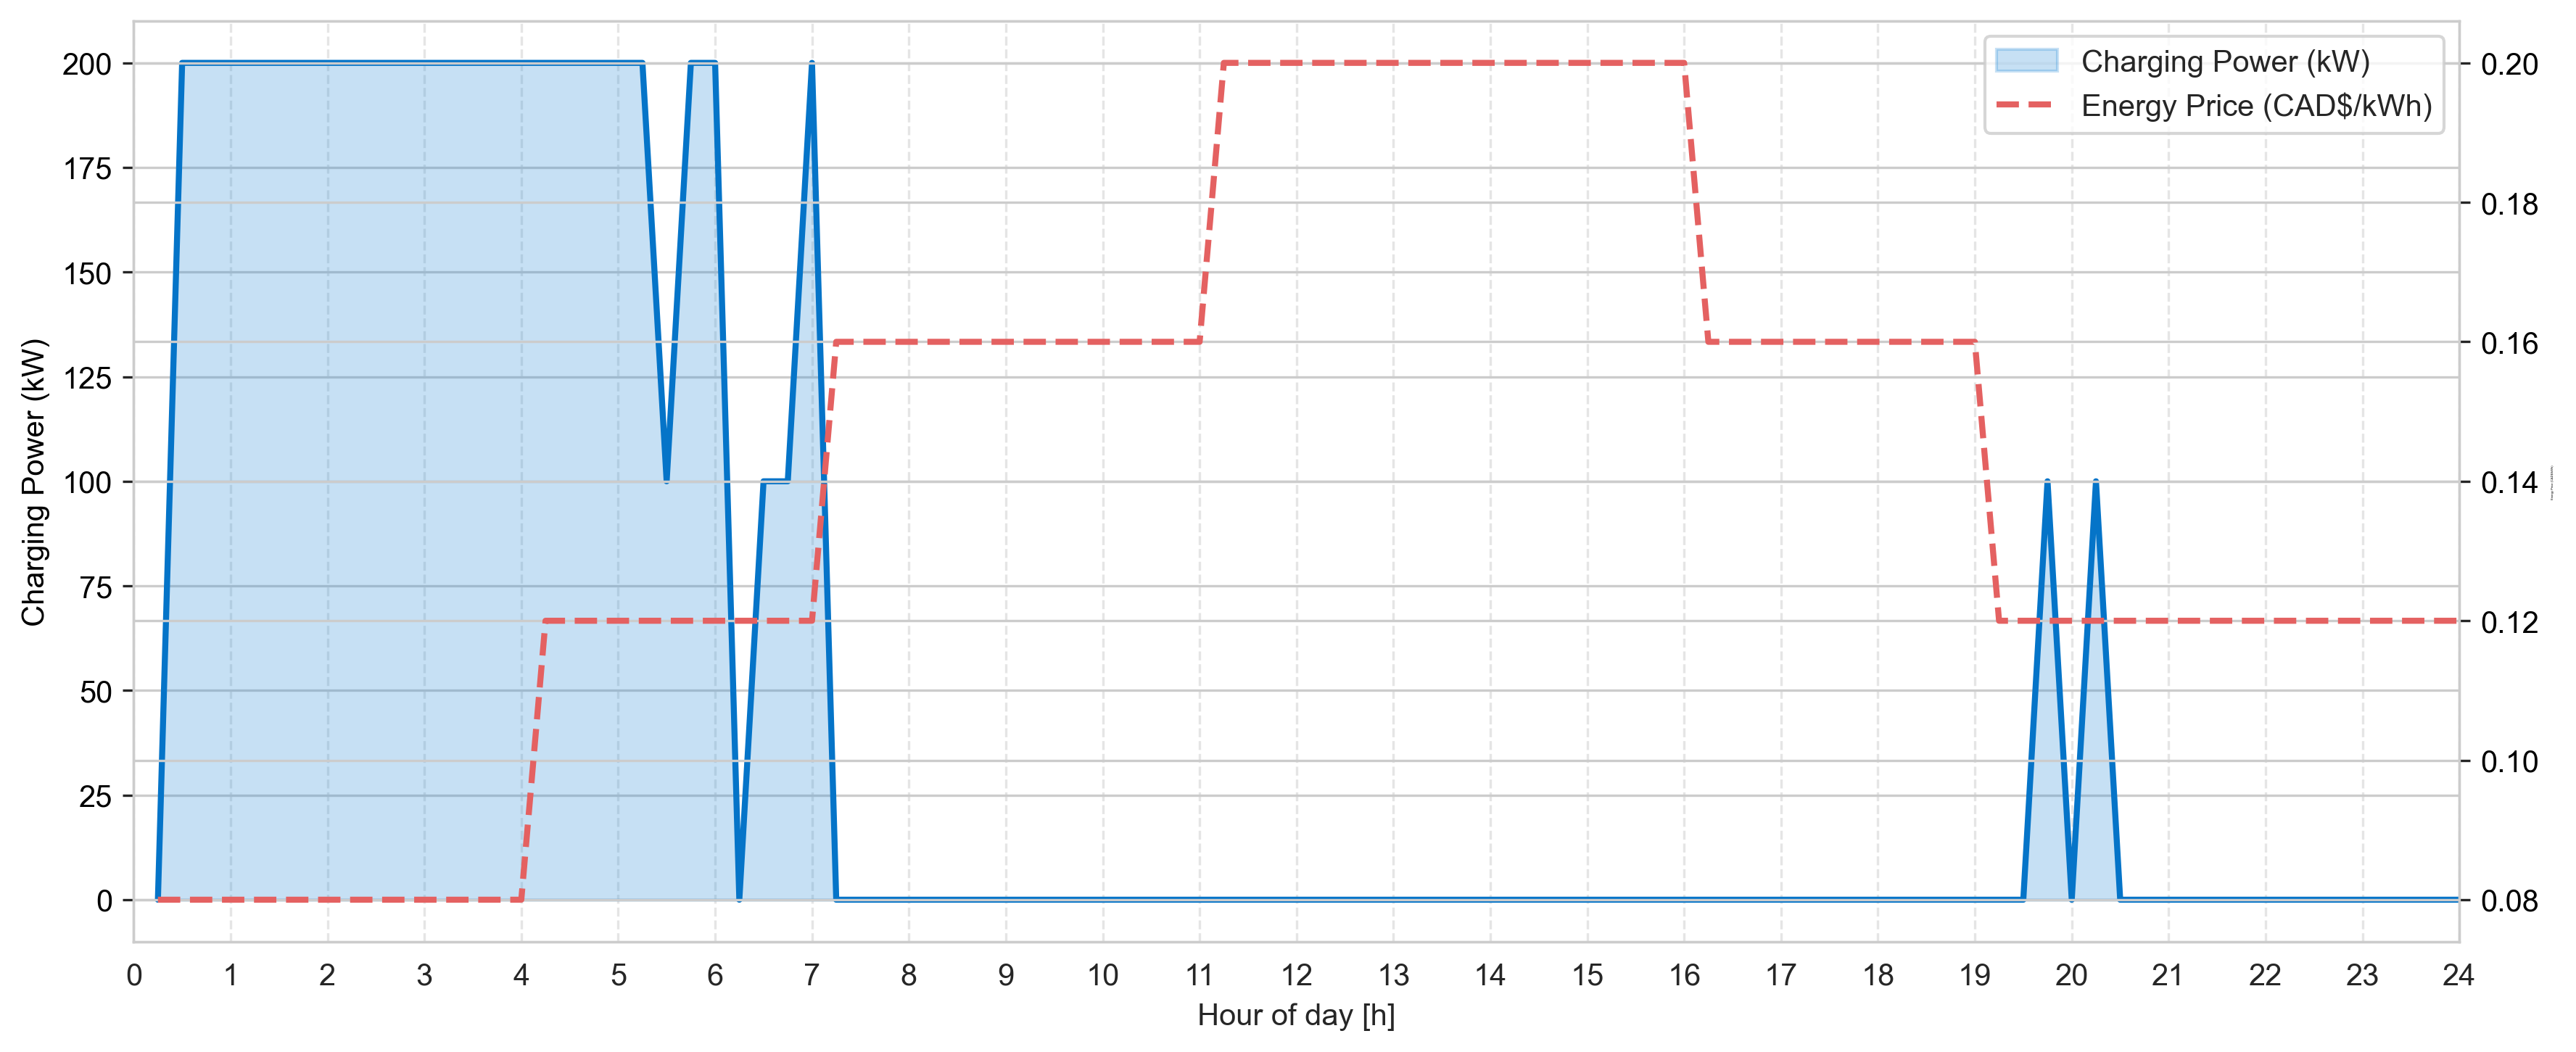

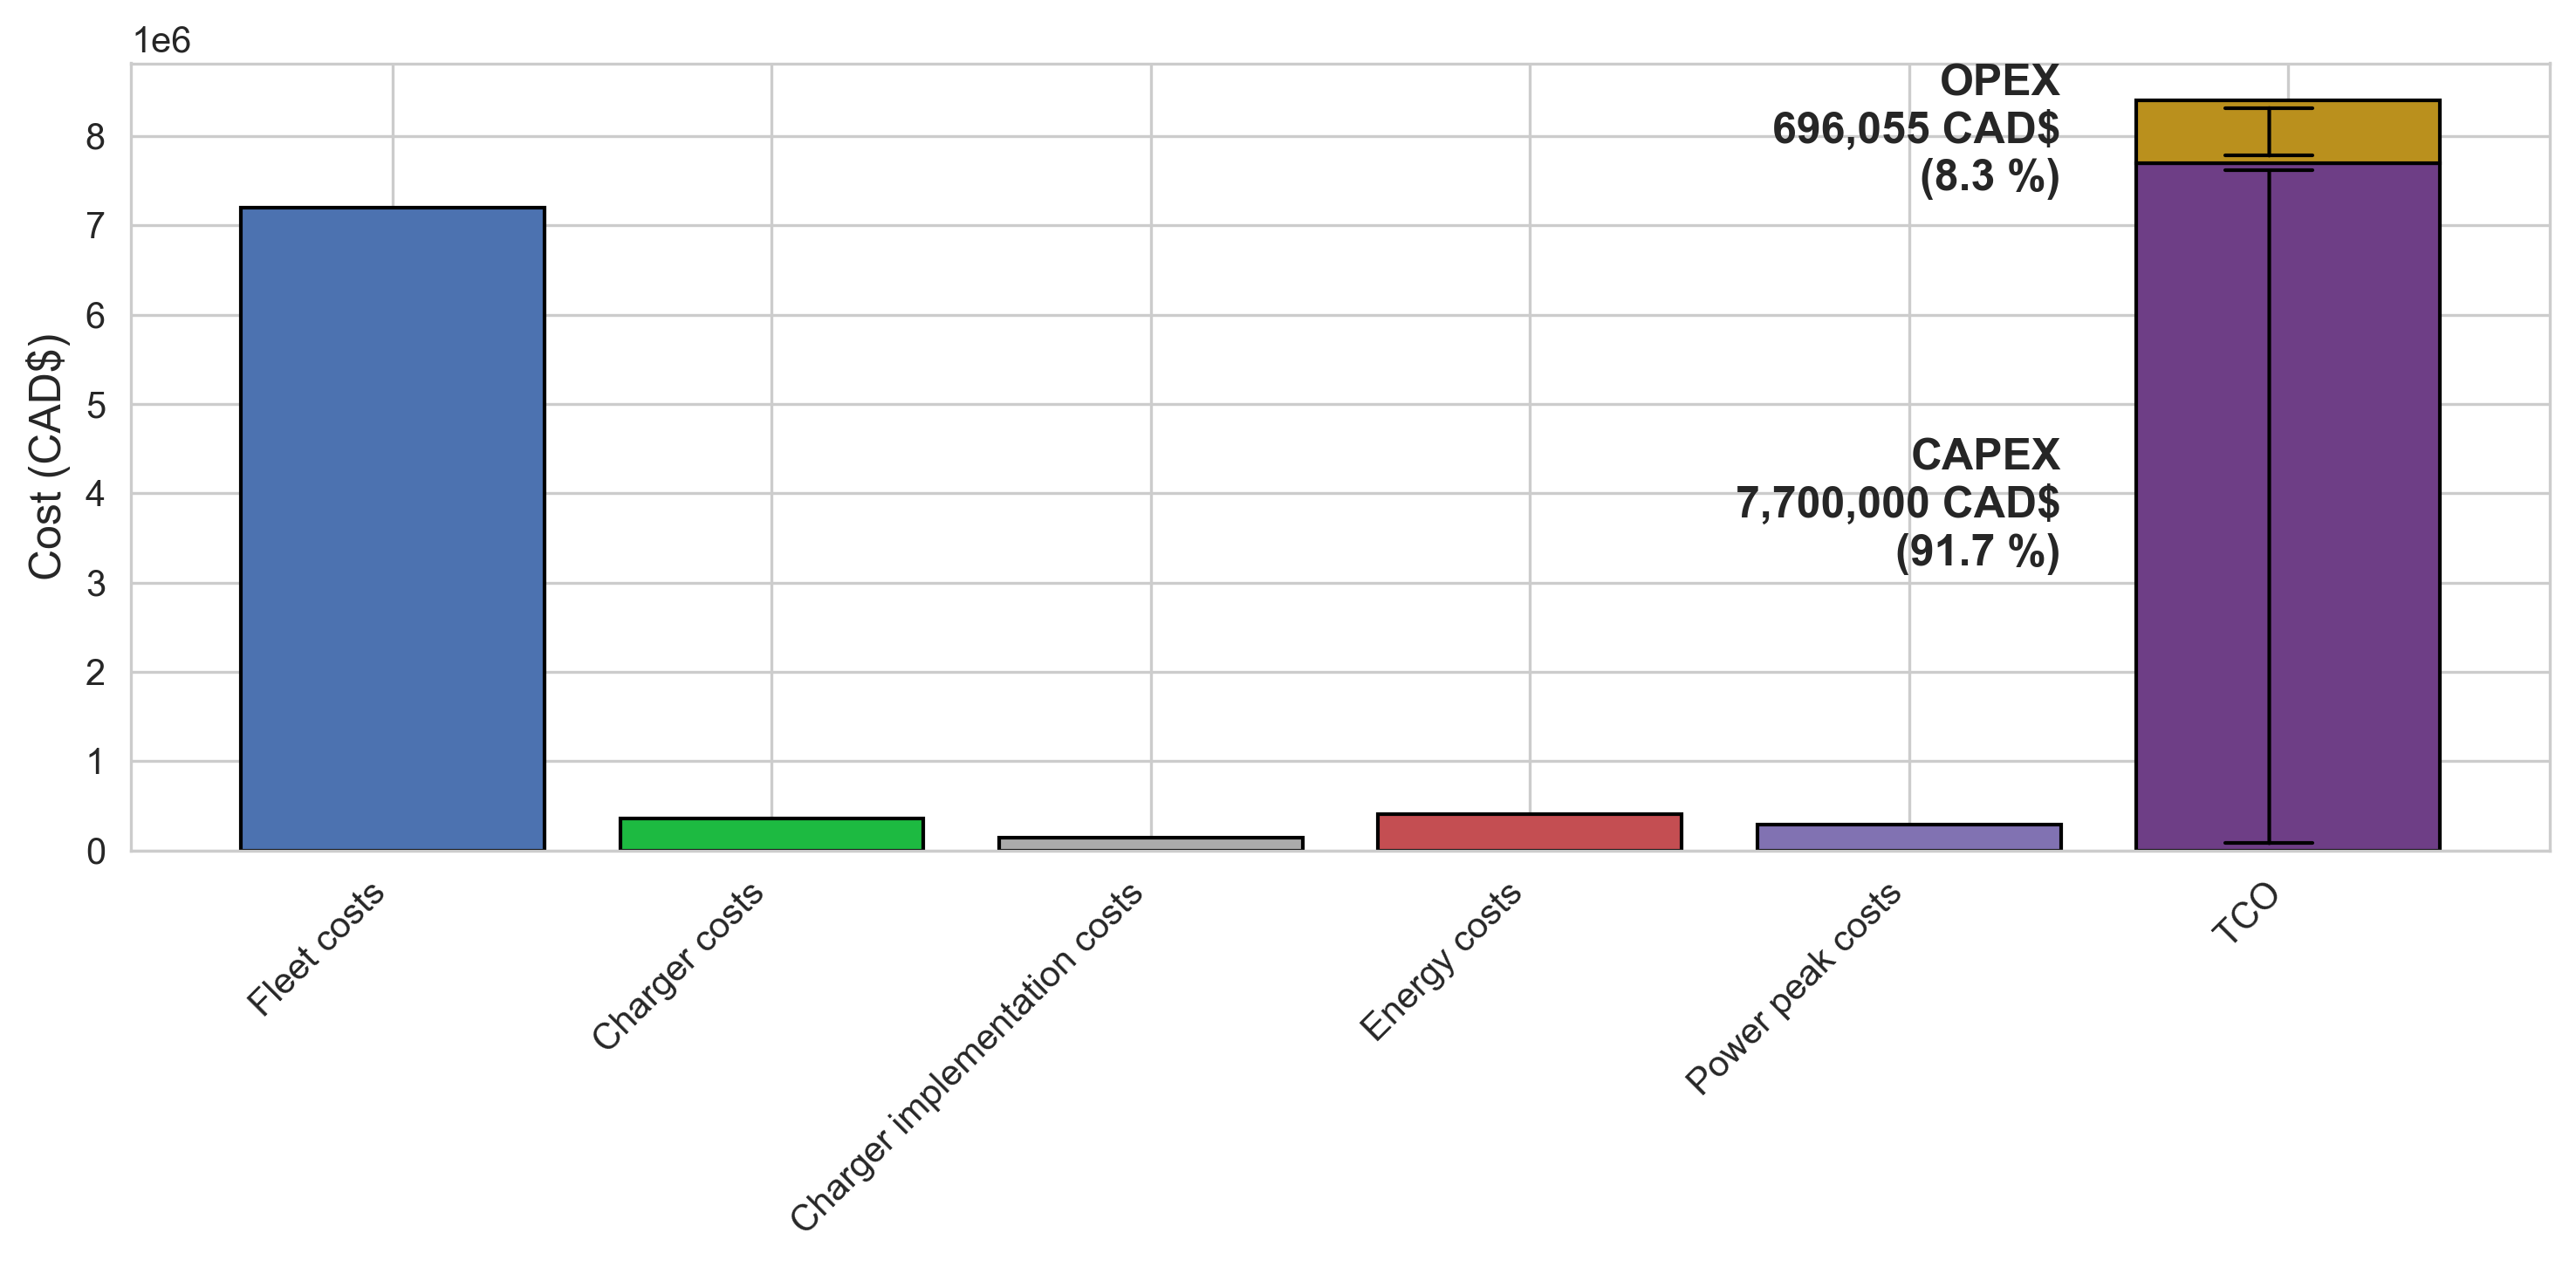

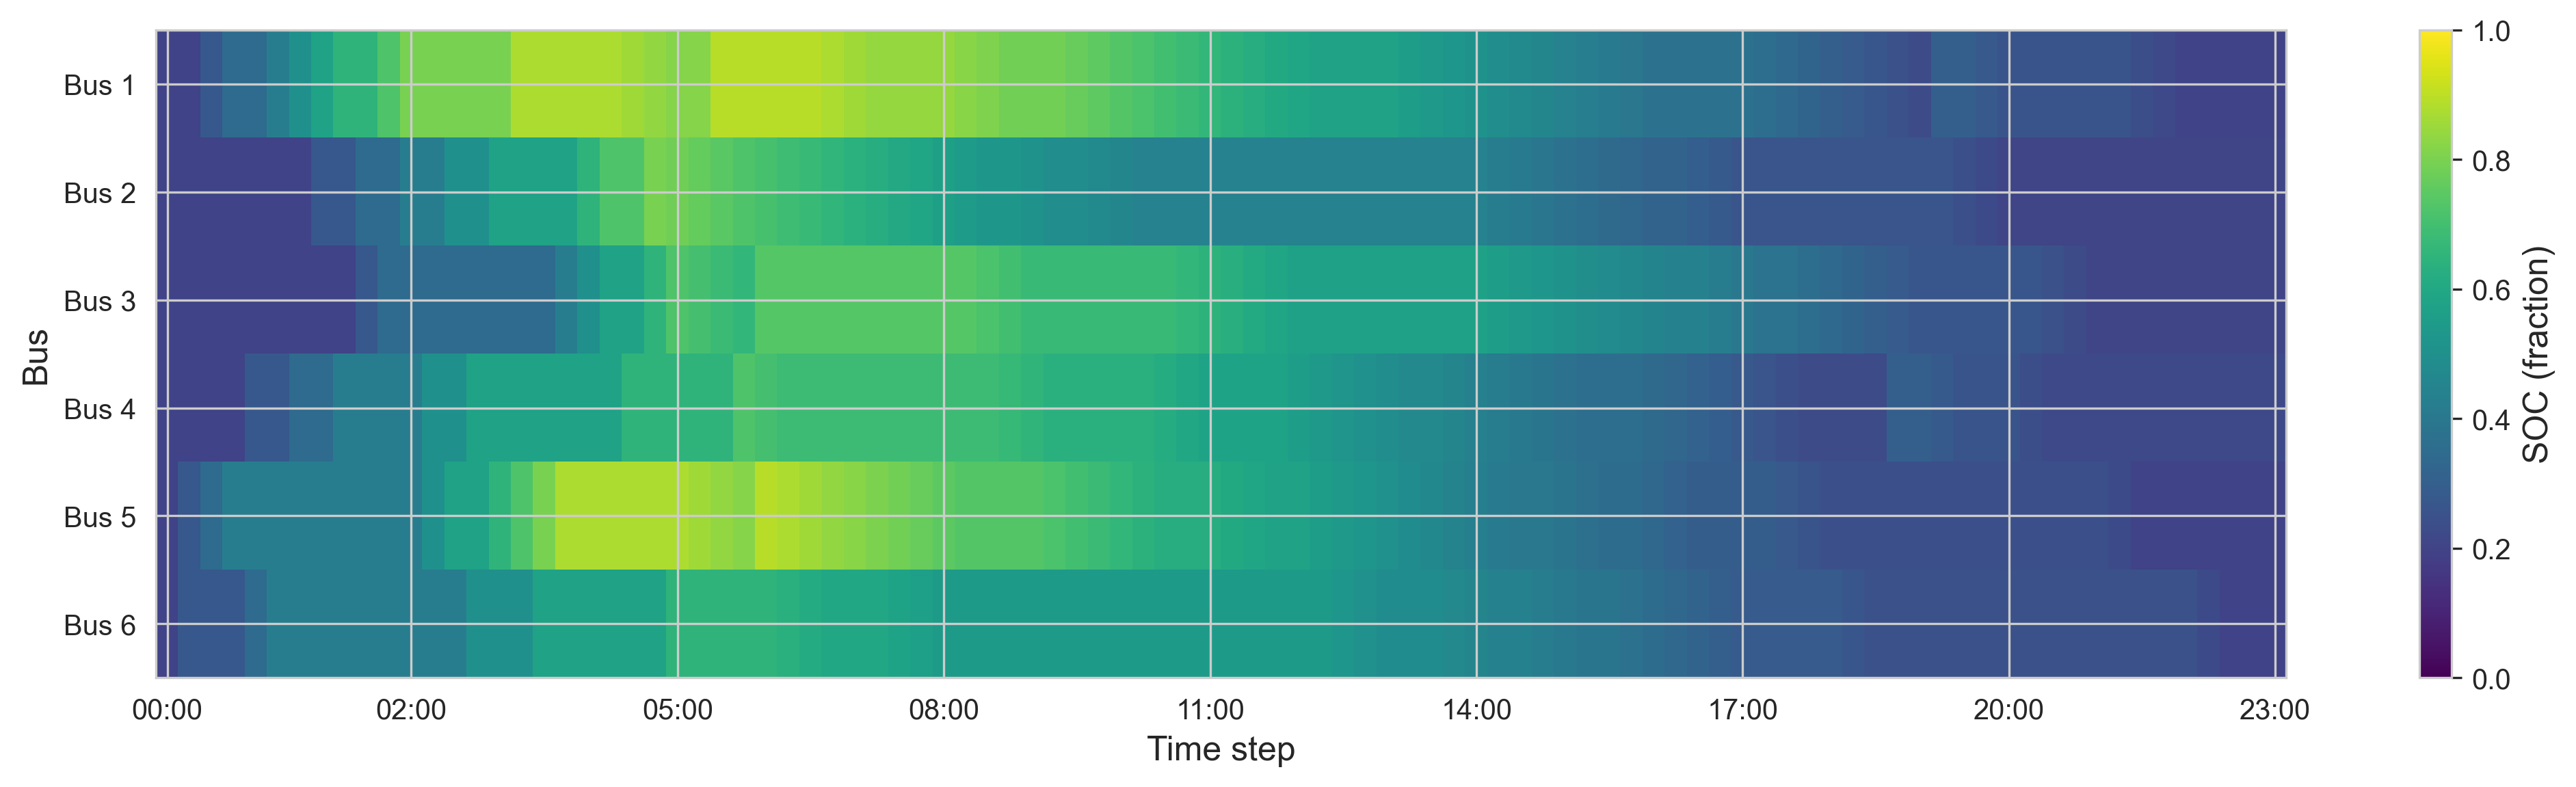

In [10]:
'''
#fast-charging example
plot_optimization_results(
    model,
    vehicle_cost=820000,    # € per bus
    charger_cost=350000,     # € per charger
    implementation_cost=300000,  # € for charger implementation
    peak_power_price=0.4,    # € per kW
    years=10
)
'''
#slow-charging example
plot_optimization_results(
    feasible_model,
    vehicle_cost=1200000,    # € per bus
    charger_cost=180000,     # € per charger
    implementation_cost=70000,  # € for charger implementation
    peak_power_price=0.4,    # € per k
    years=10
)


In [ ]:
'''
export_optimization_summary(
    model,
    vehicle_cost=820000,    # € per bus
    charger_cost=350000,     # € per charger
    implementation_cost=300000,  # € for charger implementation
    peak_power_price=0.4,    # € per kW
    years=10,
    filename='optimization_summary_fast_charging.xlsx'
)

'''
export_optimization_summary(
    feasible_model,
    vehicle_cost=1200000,    # € per bus
    charger_cost=180000,     # € per charger
    implementation_cost=70000,  # € for charger implementation
    peak_power_price=0.4,    # € per kW
    years=10,
    filename='optimization_summary_slow_charging.xlsx'
)
